<div>
<img src=https://www.institutedata.com/wp-content/uploads/2019/10/iod_h_tp_primary_c.svg width="300">
</div>

# Lab 6.3
# *KNN classification Lab*

**In this lab, we will:**
- Practice KNN classification on a dataset of breast cancer.
- Predict the `diagnoosis` of a patient from predictor variables of your choice.

### 1. Load Data

Features are computed from a digitized image of a fine needle aspirate (FNA) of a breast mass. They describe characteristics of the cell nuclei present in the image. n the 3-dimensional space is that described in: [K. P. Bennett and O. L. Mangasarian: "Robust Linear Programming Discrimination of Two Linearly Inseparable Sets", Optimization Methods and Software 1, 1992, 23-34].

This database is also available through the UW CS ftp server: ftp ftp.cs.wisc.edu cd math-prog/cpo-dataset/machine-learn/WDBC/

Also can be found on UCI Machine Learning Repository: https://archive.ics.uci.edu/ml/datasets/Breast+Cancer+Wisconsin+%28Diagnostic%29

Attribute Information:

1) ID number 2) Diagnosis (M = malignant, B = benign) 3-32)

Ten real-valued features are computed for each cell nucleus:

a) radius (mean of distances from center to points on the perimeter) b) texture (standard deviation of gray-scale values) c) perimeter d) area e) smoothness (local variation in radius lengths) f) compactness (perimeter^2 / area - 1.0) g) concavity (severity of concave portions of the contour) h) concave points (number of concave portions of the contour) i) symmetry j) fractal dimension ("coastline approximation" - 1)

The mean, standard error and "worst" or largest (mean of the three largest values) of these features were computed for each image, resulting in 30 features. For instance, field 3 is Mean Radius, field 13 is Radius SE, field 23 is Worst Radius.

All feature values are recoded with four significant digits.

Missing attribute values: none

Class distribution: 357 benign, 212 malignant

In [3]:
# IMPORT LIBRARIES
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [5]:
from google.colab import files
uploaded = files.upload()

breast_cancer_csv = 'breast-cancer-wisconsin-data.csv'
df=pd.read_csv(breast_cancer_csv)

Saving breast-cancer-wisconsin-data.csv to breast-cancer-wisconsin-data (2).csv


### 2. EDA

Explore dataset. Clean data. Find correlation.

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 33 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   id                       569 non-null    int64  
 1   diagnosis                569 non-null    object 
 2   radius_mean              569 non-null    float64
 3   texture_mean             569 non-null    float64
 4   perimeter_mean           569 non-null    float64
 5   area_mean                569 non-null    float64
 6   smoothness_mean          569 non-null    float64
 7   compactness_mean         569 non-null    float64
 8   concavity_mean           569 non-null    float64
 9   concave points_mean      569 non-null    float64
 10  symmetry_mean            569 non-null    float64
 11  fractal_dimension_mean   569 non-null    float64
 12  radius_se                569 non-null    float64
 13  texture_se               569 non-null    float64
 14  perimeter_se             5

In [7]:
df.head()

,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,...,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst,Unnamed: 32
0,842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,NaN
1,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,NaN
2,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,NaN
3,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,NaN
4,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,NaN


In [8]:
# Check class distribution
df['diagnosis'].value_counts()

,count
diagnosis,
B,357
M,212


In [9]:
# Drop 'id' and unnamed column
df.drop(['id'], axis=1, inplace=True)
df.drop(['Unnamed: 32'], axis=1, inplace=True)

In [10]:
df.head()

,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
0,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


In [11]:
# Convert M (malignant) and B (benign) into 1 and 0 for modeling.

df['diagnosis'] = df['diagnosis'].map({'M': 1, 'B': 0})

In [12]:
# Correlation analysis

correlations = df.corr()['diagnosis'].sort_values(ascending=False)
print(correlations)

diagnosis                  1.000000
concave points_worst       0.793566
perimeter_worst            0.782914
concave points_mean        0.776614
radius_worst               0.776454
perimeter_mean             0.742636
area_worst                 0.733825
radius_mean                0.730029
area_mean                  0.708984
concavity_mean             0.696360
concavity_worst            0.659610
compactness_mean           0.596534
compactness_worst          0.590998
radius_se                  0.567134
perimeter_se               0.556141
area_se                    0.548236
texture_worst              0.456903
smoothness_worst           0.421465
symmetry_worst             0.416294
texture_mean               0.415185
concave points_se          0.408042
smoothness_mean            0.358560
symmetry_mean              0.330499
fractal_dimension_worst    0.323872
compactness_se             0.292999
concavity_se               0.253730
fractal_dimension_se       0.077972
symmetry_se               -0

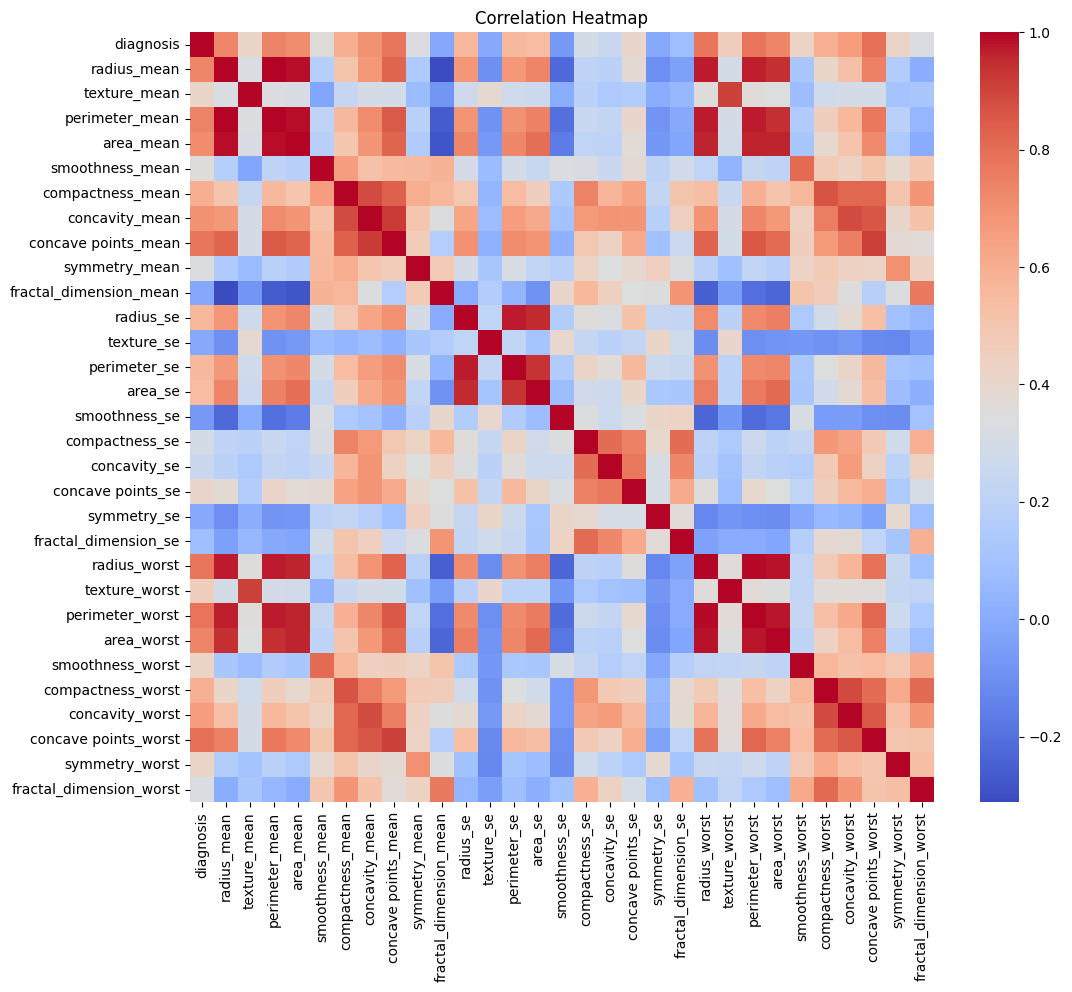

In [13]:
# Visualise with a heatmap

plt.figure(figsize=(12,10))
sns.heatmap(df.corr(), cmap='coolwarm', annot=False, fmt=".2f")
plt.title("Correlation Heatmap")
plt.show()

### 3. Set up the `diagnosis` variable as your target. How many classes are there?

In [16]:
# ANSWER

target = df['diagnosis']

print("Unique classes in the target:", target.unique())
print("Class counts:\n", target.value_counts())
print("Number of classes:", target.nunique())

Unique classes in the target: [1 0]
Class counts:
 diagnosis
0    357
1    212
Name: count, dtype: int64
Number of classes: 2


### 4. What is the baseline accuracy?

In [18]:
# ANSWER
# Count the frequency of each class
class_counts = df['diagnosis'].value_counts()

# Calculate baseline accuracy as (count of majority class) / (total number of samples)
baseline_accuracy = class_counts.max() / class_counts.sum()

print(f"Baseline Accuracy: {baseline_accuracy:.2%}")

Baseline Accuracy: 62.74%


### 5. Choose features to be your predictor variables and set up your X.

In [19]:
# ANSWER
top_features = correlations[abs(correlations) > 0.5].index.tolist()
top_features.remove('diagnosis')  # Remove target
print("Top features for modeling:", top_features)

Top features for modeling: ['concave points_worst', 'perimeter_worst', 'concave points_mean', 'radius_worst', 'perimeter_mean', 'area_worst', 'radius_mean', 'area_mean', 'concavity_mean', 'concavity_worst', 'compactness_mean', 'compactness_worst', 'radius_se', 'perimeter_se', 'area_se']


In [21]:
X = df[top_features]
y = df['diagnosis']
print("X shape:", X.shape)
print("Feature names:", X.columns.tolist())


X shape: (569, 15)
Feature names: ['concave points_worst', 'perimeter_worst', 'concave points_mean', 'radius_worst', 'perimeter_mean', 'area_worst', 'radius_mean', 'area_mean', 'concavity_mean', 'concavity_worst', 'compactness_mean', 'compactness_worst', 'radius_se', 'perimeter_se', 'area_se']


### 6. Fit a `KNeighborsClassifier` with 1 neighbor using the target and predictors.

In [22]:
# ANSWER
# Make an instance of a KNeighborsClassifier object with 1 neighbor
from sklearn.neighbors import KNeighborsClassifier
knn = KNeighborsClassifier(n_neighbors=1)

# fit on the unstandardized data:
knn.fit(X, y)

KNeighborsClassifier(n_neighbors=1)

### 7. Evaluate the accuracy of your model.
- Is it better than baseline?
- Is it legitimate?

In [28]:
# ANSWER
# predict the response values for the observations in X ("test the model")
from sklearn.metrics import accuracy_score
y_pred = knn.predict(X)
# store the predicted response values
# use this to compute the accuracy
accuracy = accuracy_score(y, y_pred)
print(f"Training Accuracy: {accuracy:.2%}")

Training Accuracy: 100.00%


In [30]:
baseline = df['diagnosis'].value_counts(normalize=True).max()
print(f"Baseline Accuracy: {baseline:.2%}")

Baseline Accuracy: 62.74%


It is much better than the baseline, but it is not legitimate because we're evaluating on the same data the model was trained on (overfitting risk)

With k=1, KNN memorizes training data, and will often return 100% training accuracy.

Also, no generalization test has been done yet.



### 8. Create a 80-20 train-test-split of your target and predictors. Refit the KNN and assess the accuracy.

In [31]:
# ANSWER
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score
# STEP 1: split X and y into training and testing sets (using random_state for reproducibility)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
# STEP 2: train the model on the training set (using K=1)
knn = KNeighborsClassifier(n_neighbors=1)
knn.fit(X_train, y_train)

# STEP 3: test the model on the testing set, and check the accuracy
y_pred_test = knn.predict(X_test)
# Evaluate accuracy
test_accuracy = accuracy_score(y_test, y_pred_test)
print(f"Test Accuracy (K=1, unscaled): {test_accuracy:.2%}")

Test Accuracy (K=1, unscaled): 89.47%


### 9. Evaluate the test accuracy of a KNN where K == number of rows in the training data.

In [32]:
# ANSWER
# Create an instance of KNeighborsClassifier where n_neighbors = number of rows in the training data
k_max = X_train.shape[0]
knn_max = KNeighborsClassifier(n_neighbors=k_max)

# Fit Train Data
knn_max.fit(X_train, y_train)
y_pred_max_k = knn_max.predict(X_test)

# Print accuracy_score
accuracy_max_k = accuracy_score(y_test, y_pred_max_k)
print(f"Test Accuracy with K={k_max}: {accuracy_max_k:.2%}")

Test Accuracy with K=455: 63.16%


### 10. Fit the KNN at values of K from 1 to the number of rows in the training data.
- Store the test accuracy in a list.
- Plot the test accuracy vs. the number of neighbors.

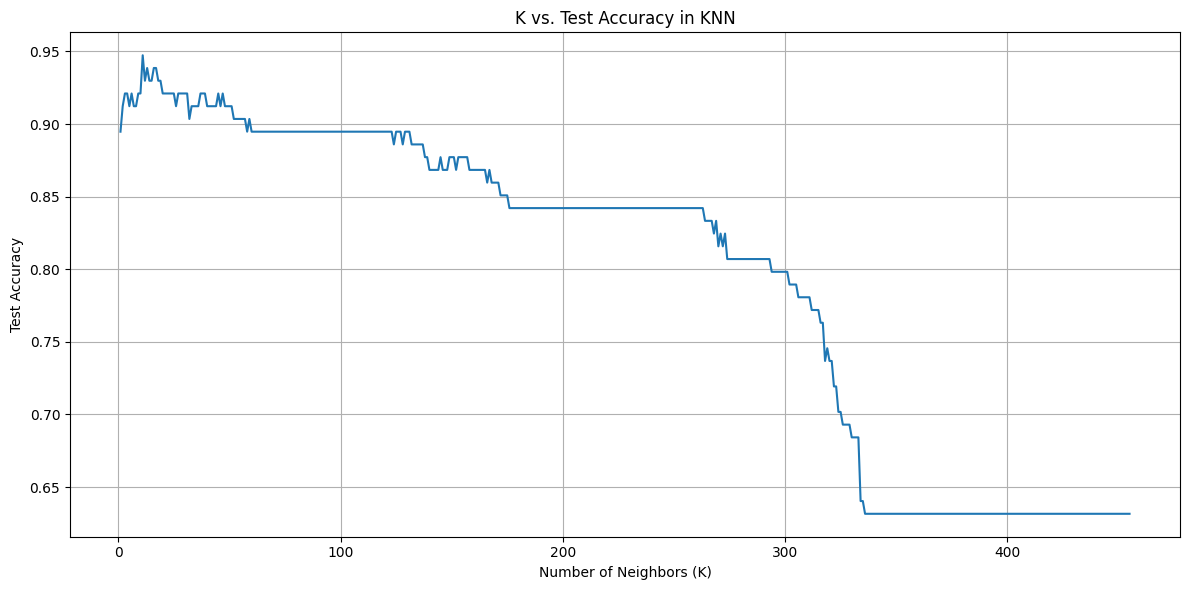

In [35]:
# ANSWER
# plot test accuracy by number of neighbors:
test_accuracies = []
# Loop over k from 1 to max_k
for k in range(1, k_max + 1):
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train, y_train)
    y_pred = knn.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    test_accuracies.append(acc)

# Plotting
plt.figure(figsize=(12,6))
plt.plot(range(1, k_max + 1), test_accuracies)
plt.xlabel('Number of Neighbors (K)')
plt.ylabel('Test Accuracy')
plt.title('K vs. Test Accuracy in KNN')
plt.grid(True)
plt.tight_layout()
plt.show()


### 11. Fit KNN across different values of K and plot the mean cross-validated accuracy with 5 folds.


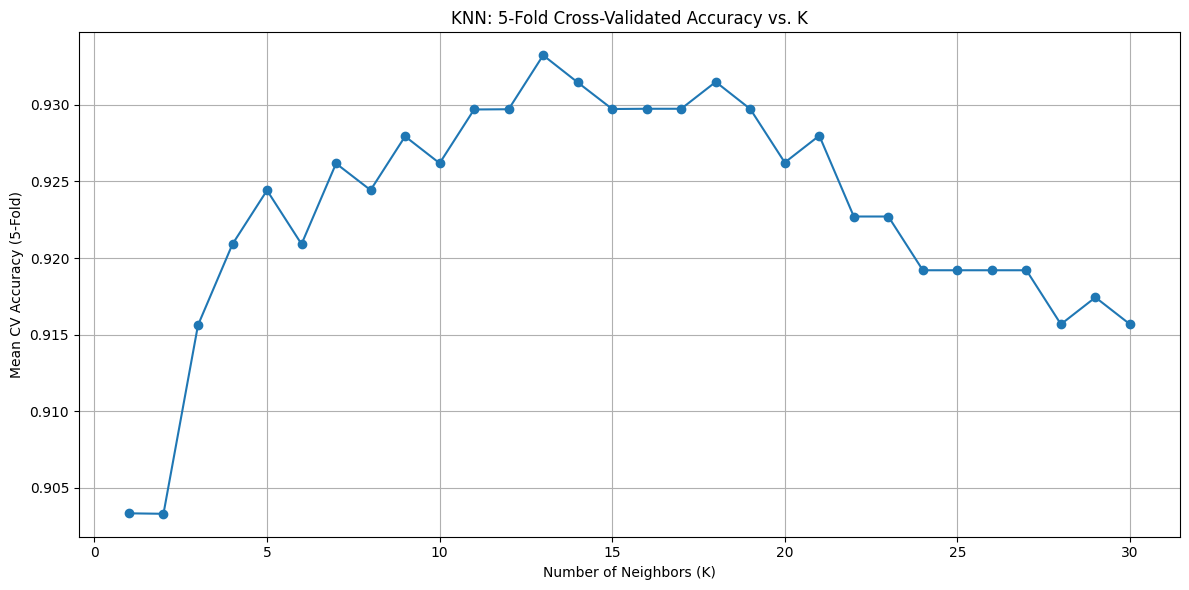

In [36]:
# ANSWER
from sklearn.model_selection import cross_val_score
# Set range for K values
max_k = 30
cv_scores = []

# Loop through values of k
for k in range(1, max_k + 1):
    knn = KNeighborsClassifier(n_neighbors=k)
    # Perform 5-fold cross-validation and compute mean accuracy
    scores = cross_val_score(knn, X, y, cv=5, scoring='accuracy')
    cv_scores.append(scores.mean())

# Plot
plt.figure(figsize=(12,6))
plt.plot(range(1, max_k + 1), cv_scores, marker='o')
plt.xlabel('Number of Neighbors (K)')
plt.ylabel('Mean CV Accuracy (5-Fold)')
plt.title('KNN: 5-Fold Cross-Validated Accuracy vs. K')
plt.grid(True)
plt.tight_layout()
plt.show()

### 12. Standardize the predictor matrix and cross-validate across the different K.
- Plot the standardized mean cross-validated accuracy against the unstandardized. Which is better?
- Why?

In [37]:
# ANSWER
# Standarize X
from sklearn.preprocessing import StandardScaler
# 1. Standardize the predictor matrix
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
# 2. Set K range
max_k = 30
cv_scores_raw = []
cv_scores_scaled = []
# 3. Loop through values of K and perform 5-fold cross-validation
for k in range(1, max_k + 1):
    knn = KNeighborsClassifier(n_neighbors=k)

    # CV on unstandardized data
    scores_raw = cross_val_score(knn, X, y, cv=5, scoring='accuracy')
    cv_scores_raw.append(scores_raw.mean())

    # CV on standardized data
    scores_scaled = cross_val_score(knn, X_scaled, y, cv=5, scoring='accuracy')
    cv_scores_scaled.append(scores_scaled.mean())

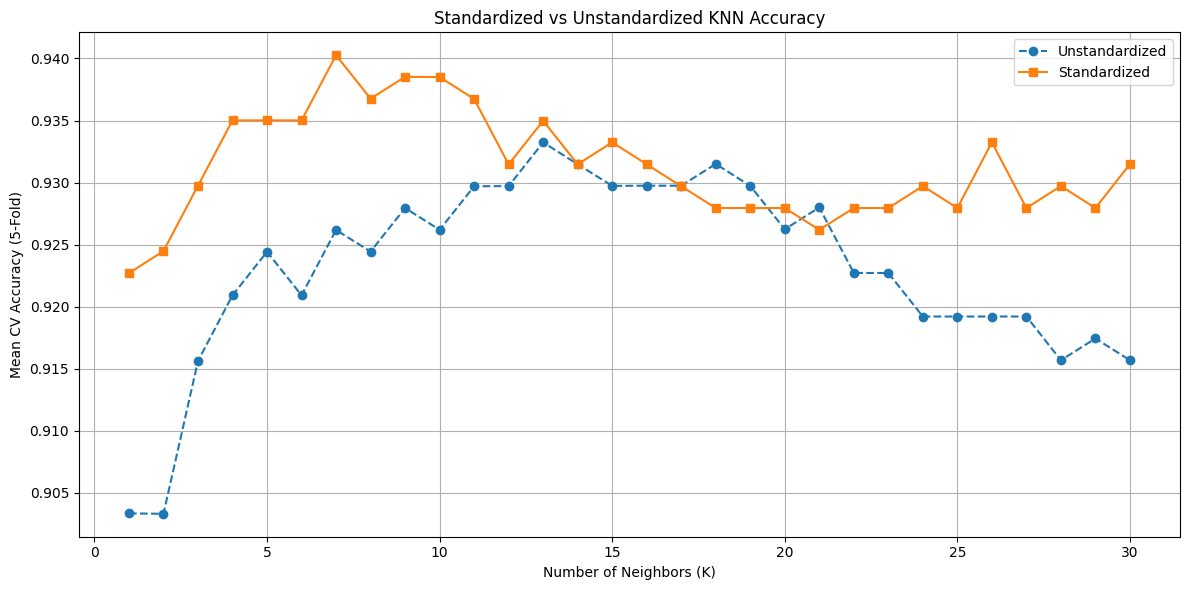

In [38]:
# ANSWER
# plot test accuracy by number of neighbors:
plt.figure(figsize=(12, 6))
plt.plot(range(1, max_k + 1), cv_scores_raw, label='Unstandardized', linestyle='--', marker='o')
plt.plot(range(1, max_k + 1), cv_scores_scaled, label='Standardized', linestyle='-', marker='s')
plt.xlabel('Number of Neighbors (K)')
plt.ylabel('Mean CV Accuracy (5-Fold)')
plt.title('Standardized vs Unstandardized KNN Accuracy')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


Standardised is better because KNN relies on distance (Euclidean) between points.

Without scaling, features with larger magnitudes dominate distance calculations

Standardisation ensures all features contribute equally

**References**

[Breast Cancer Wisconsin (Diagnostic) Data Set](https://www.kaggle.com/uciml/breast-cancer-wisconsin-data/downloads/breast-cancer-wisconsin-data.zip/2)



---



---



> > > > > > > > > © 2025 Institute of Data


---



---



